In [30]:
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd

from mmkin import KineticsSeries, mm_dimer, fit_mm_dimer, mm, fit_mm


In [31]:
mutants = ['wt', 'N214A', 'Q256A', 'S284A']
mutant_colors  = ['k', 'b', 'g', 'orange']

ks_s = [
        KineticsSeries('./wt/wt.yaml', corrections='./config.yaml', prefix='./wt'),
        KineticsSeries('./N214A/n214a.yaml', corrections='./config.yaml', prefix='./N214A'),
        KineticsSeries('./Q256A/q256a.yaml', corrections='./config.yaml', prefix='./Q256A'),
        KineticsSeries('./S284A/s284a.yaml', corrections='./config.yaml', prefix='./S284A'),
       ]

normal_ps = [2.0, 5.0, 10.0, 20.0, 40.0, 80.0, 160.0]
ss = np.array([320.0, 160.0, 80.0, 40.0, 20.0, 10.0, 5.0])

# N214A experiments were performed to higher final concentration
# show the same number of total points -- lower concentrations not active
n214a_ps = [20.0, 40.0, 80.0, 160.0, 320.0, 640.0, 1280.0]

Loading: 210401_2µM_MproWT.csv...
 ... excluded
Loading: 210401_buffer_200µM_MproWT.csv...
 ... excluded
Loading: 210413_02_002µM_MproWT.csv...
 ... excluded
Loading: 210413_buffer_2µM_MproWT.csv...
 ... excluded
Loading: 210420_20µM_MproWT.csv...
 ... excluded
Loading: 210420_10µM_MproWT.csv...
 ... excluded
Loading: 210420_5_and_2µM_MproWT.csv...
 ... excluded
Loading: 210430_20_10_5_and_2µM_MproWT.csv...
Loading: 210430_buffer_160_80_and_40µM_MproWT.csv...
 ... excluding E=160.00 / S=160.00
Loading: 210507_buffer_20µM_MproWT_N_Q_S.csv...
 ... excluded
Loading: 210507_10µM_MproWT_N_Q_S.csv...
 ... excluded
Loading: 210414_20_2_02_002µM_MproN214A.csv...
 ... excluded
Loading: 210421_20_and_10_µM_MproN214A.csv...
 ... excluded
Loading: 210421_5_and_2_µM_MproN214A.csv...
 ... excluded
Loading: 210427_buffer_160_and_80µM_MproN214A.csv...
 ... excluded
Loading: 210427_buffer_160_and_80µM_MproN214A_2.csv...
 ... excluded
Loading: 210427_40_20_and_10µM_MproN214A.csv...
 ... excluding E=20.0

In [32]:
for ks in ks_s:
    ks.fit_v0(r2_threshold=0.0)

In [33]:
# write v0 data to excel
with pd.ExcelWriter('fit_velocities.xlsx') as writer:
    for ik, ks in enumerate(ks_s):
        mutant_name = mutants[ik]
        df = pd.DataFrame(ks.get_fit_v0_as_json())
        df = df.sort_values(by=['[E] (µM)', '[S] (µM)']).reset_index(drop=True)
        df.to_excel(writer, sheet_name=mutant_name, index=False)

In [34]:
colormap = plt.get_cmap('plasma_r')

def set_color(concentration):
    scale = np.log2(concentration / 2.0) / 11.0 + 0.12
    return colormap(scale)

	k_cat (1/min)		K_m (µM)	K_d (µM)
	-------------		--------	--------
wt	0.88 +/- 0.019	87.4 +/- 2.0	0.488 +/- 0.019
N214A	588375.45 +/- 14582.160	1903630028.3 +/- 0.0	0.000 +/- 0.000
Q256A	0.44 +/- 0.022	55.8 +/- 3.2	0.977 +/- 0.093
S284A	0.66 +/- 0.017	60.3 +/- 1.7	0.284 +/- 0.016

Errors are a 95% confidence interval (Z=1.96) on the fit parameters.


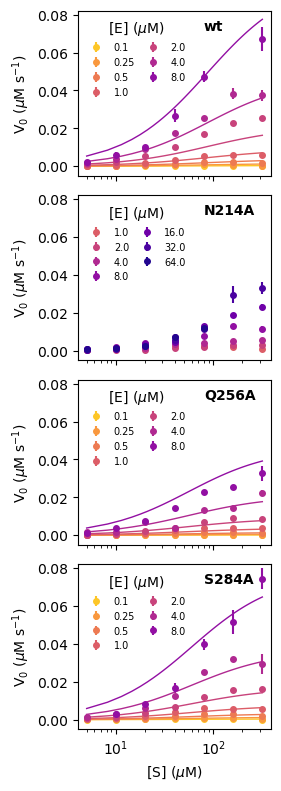

In [35]:
Z_star = 1.96 # 95% CI

S = np.linspace(ss.min(), ss.max(), 100)

fig, axes = plt.subplots(4, 1, figsize=(3,8), sharex=True)

print('\tk_cat (1/min)\t\tK_m (µM)\tK_d (µM)')
print('\t-------------\t\t--------\t--------')

for im, m in enumerate(mutants):
    
    ks = ks_s[im]

    ax = axes[im]
    ax.text(80, 0.072, m, weight="bold")

    # fit to dimer activity model, different enzyme conc for N214A
    if m == 'N214A':
        ps = n214a_ps
    else:
        ps = normal_ps
    
    s0s, p0s, v0s, v0errs = ks.get_set_v0s(ps, ss)
    
    # there is an issue with some fits failing
    # and the errors are set to zero -- discard these
    good = (v0errs != 0.0)
    s0s = s0s[good]
    p0s = p0s[good]
    v0s = v0s[good]
    v0errs = v0errs[good]

    # parameters: k_cat, K_m, K_d
    # note: divide by 20 to account for dilution in experiment
    popt, perr = fit_mm_dimer(v0s, s0s, p0s / 20.0, v0errs=v0errs)
    
    for i,p in enumerate(ps):
        s0s, _, v0s, v0errs = ks.get_set_v0s([p], ss)
        ax.errorbar(s0s, v0s, fmt='.', yerr=v0errs, c=set_color(p), markersize=8)

    for i,p in enumerate(ps):
        V_fit = mm_dimer( p / 20.0, S, *popt)
        if m != 'N214A':
            ax.plot(S, V_fit, lw=1, c=set_color(p), label="_nolegend_")

    fmt_params = [m]
    for i in range(3):
        fmt_params.append(popt[i])
        fmt_params.append(perr[i] * Z_star)
        
    # convert 1/s to 1/min
    fmt_params[1] = float(fmt_params[1]) * 60.0  # kcat
    fmt_params[2] = float(fmt_params[2]) * 60.0  # error on kcat

    print('%s\t%.2f +/- %.3f\t%.1f +/- %.1f\t%.3f +/- %.3f' % tuple(fmt_params))

    ax.set_xscale('log')
    if im == 3:
        ax.set_xlabel('[S] ($\mu$M)')

    ax.set_ylim([-0.005, 0.082])
    ax.set_ylabel('V$_0$ ($\mu$M s$^{-1}$)')

    ax.legend(
        np.array(ps) / 20.0,
        title='[E] ($\mu$M)',
        fontsize=7,
        loc=2,
        frameon=False,
        ncol=2,
        columnspacing=0.8,
    )

print("\nErrors are a 95% confidence interval (Z=1.96) on the fit parameters.")

plt.tight_layout()
plt.savefig('figures/mm_dimer-linreg_error.pdf')
plt.show()

### fit a single concentration, above the monomer/dimer Kd, to Michaelis-Menten

	k_cat (1/min)		K_m (µM)
	-------------		--------
wt	1.01 +/- 0.288	240.1 +/- 76.0
N214A	0.16 +/- 0.024	104.5 +/- 21.7
Q256A	0.34 +/- 0.048	100.5 +/- 21.1
S284A	1.59 +/- 0.616	525.4 +/- 232.4

Errors are a 95% confidence interval (Z=1.96) on the fit parameters.


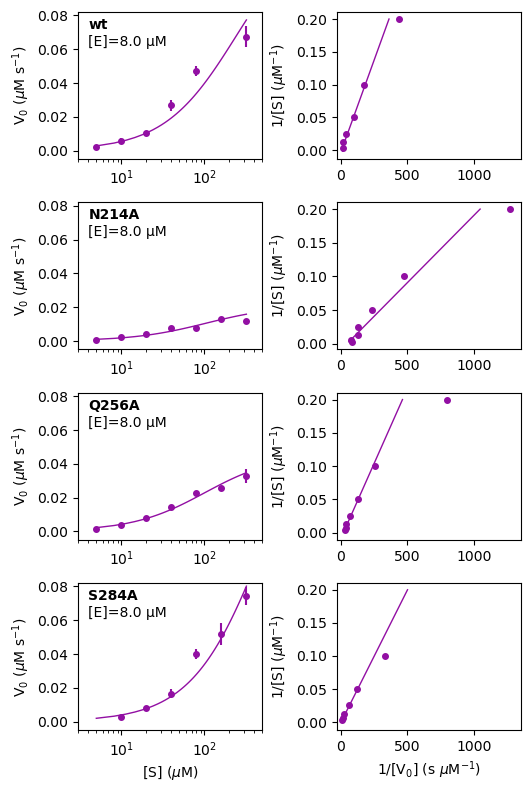

In [36]:
fig, axes = plt.subplots(4, 2, figsize=(5.5,8))

print('\tk_cat (1/min)\t\tK_m (µM)')
print('\t-------------\t\t--------')

for im, m in enumerate(mutants):
    
    ks = ks_s[im]
    ax = axes[im,0]
    

    # fit to dimer activity model, different enzyme conc for N214A
    if m == 'N214A':
        ps = 8.0 * 20.0
    else:
        ps = 8.0 * 20.0
    axes[im,0].text(4, 0.072, m, weight="bold")
    axes[im,0].text(4, 0.062, f"[E]={ps / 20.0} µM")

    s0s, _, v0s, v0errs = ks.get_set_v0s([ps], ss)
    
    # there is an issue with some fits failing
    # and the errors are set to zero -- discard these
    good = (v0errs != 0.0)
    s0s = s0s[good]
    v0s = v0s[good]
    v0errs = v0errs[good]

    # parameters: k_cat, K_m, K_d
    # note: divide by 20 to account for dilution in experiment
    
    popt, perr = fit_mm(v0s, s0s, ps / 20.0, v0errs=v0errs)
    V_fit = mm(ps / 20.0, S, *popt)
    
    # left hand -- log/lin
    axes[im,0].errorbar(s0s, v0s, fmt='.', yerr=v0errs, c=set_color(p), markersize=8)
    axes[im,0].plot(S, V_fit, lw=1, c=set_color(p), label="_nolegend_")

    # right hand -- 
    axes[im,1].errorbar(1.0 / v0s, 1.0 / s0s, fmt='.', yerr=v0errs, c=set_color(p), markersize=8)
    axes[im,1].plot(1.0 / V_fit, 1.0 / S, lw=1, c=set_color(p), label="_nolegend_")


    fmt_params = [m]
    for i in range(2):
        fmt_params.append(popt[i])
        fmt_params.append(perr[i] * Z_star)

    # convert 1/s to 1/min
    fmt_params[1] = float(fmt_params[1]) * 60.0  # kcat
    fmt_params[2] = float(fmt_params[2]) * 60.0  # error on kcat

    print('%s\t%.2f +/- %.3f\t%.1f +/- %.1f' % tuple(fmt_params))

    axes[im,0].set_xscale('log')
    if im == 3:
        axes[im,0].set_xlabel('[S] ($\mu$M)')
        axes[im,1].set_xlabel('1/[V$_0$] (s $\mu$M$^{-1}$)')

    axes[im,0].set_ylim([-0.005, 0.082])
    axes[im,0].set_ylabel('V$_0$ ($\mu$M s$^{-1}$)')
    axes[im,0].set_xlim([3, 500])

    axes[im,1].set_ylabel('1/[S] ($\mu$M$^{-1}$)')
    axes[im,1].set_xlim([-30, 1350])

print("\nErrors are a 95% confidence interval (Z=1.96) on the fit parameters.")

plt.tight_layout()
#plt.savefig('figures/mm_dimer-linreg_error.pdf')
plt.show()

	[E]	k_cat (1/min)	K_m (µM)
	---	-------------	--------
wt	0.25	0.18 +/- 0.091	13.5 +/- 28.6
wt	0.50	0.29 +/- 0.104	37.9 +/- 44.0
wt	1.00	0.45 +/- 0.104	56.5 +/- 37.8
wt	2.00	1.02 +/- 0.127	91.4 +/- 28.0
wt	4.00	0.75 +/- 0.138	75.3 +/- 36.5
wt	8.00	0.67 +/- 0.145	92.8 +/- 47.9
N214A	2.00	0.12 +/- 0.022	81.8 +/- 39.7
N214A	4.00	0.10 +/- 0.015	48.6 +/- 21.7
N214A	8.00	0.11 +/- 0.023	46.7 +/- 30.6
N214A	16.00	0.14 +/- 0.037	174.2 +/- 92.9
N214A	32.00	0.13 +/- 0.088	305.1 +/- 352.1
N214A	64.00	0.09 +/- 0.269	553.9 +/- 1814.7
Q256A	0.50	0.21 +/- 0.063	27.4 +/- 28.8
Q256A	1.00	0.30 +/- 0.061	45.7 +/- 28.6
Q256A	2.00	0.35 +/- 0.087	69.6 +/- 46.7
Q256A	4.00	0.47 +/- 0.210	145.9 +/- 138.6
Q256A	8.00	0.30 +/- 0.038	74.0 +/- 24.7
S284A	0.25	0.20 +/- 0.083	8.9 +/- 17.4
S284A	0.50	0.34 +/- 0.143	25.8 +/- 38.2
S284A	1.00	0.41 +/- 0.113	37.5 +/- 33.0
S284A	2.00	0.64 +/- 0.127	76.7 +/- 39.8
S284A	4.00	0.61 +/- 0.171	71.1 +/- 53.6
S284A	8.00	0.93 +/- 0.260	210.7 +/- 112.0

Errors are a 95% confidence i

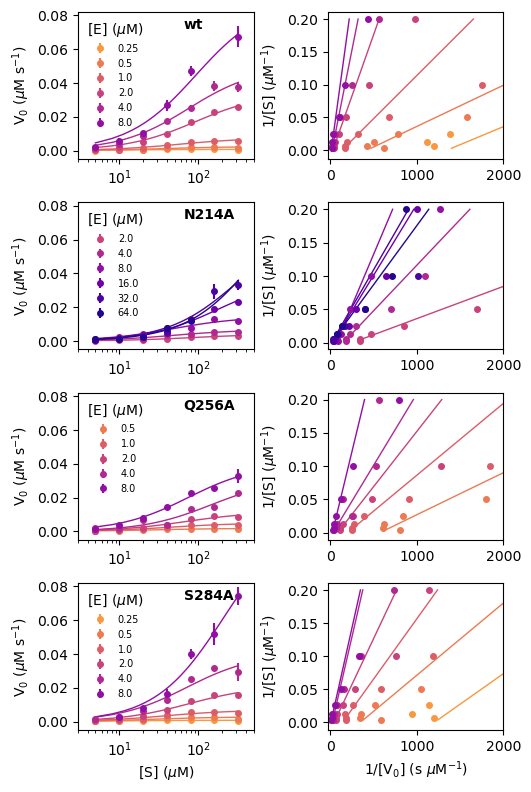

In [124]:
resulting_data = {m : [] for m in mutants}

fig, axes = plt.subplots(4, 2, figsize=(5.5,8))

print('\t[E]\tk_cat (1/min)\tK_m (µM)')
print('\t---\t-------------\t--------')

for im, m in enumerate(mutants):
    
    ks = ks_s[im]
    ax = axes[im,0]

    # fit to dimer activity model, different enzyme conc for N214A
    if m == 'N214A':
        ps = n214a_ps[1:]
    elif m == 'Q256A':
        ps = normal_ps[2:]
    else:
        ps = normal_ps[1:]

    axes[im,0].text(65, 0.072, m, weight="bold")
    
    for p in ps:

        # parameters: k_cat, K_m, K_d
        # note: divide by 20 to account for dilution in experiment
        s0s, _, v0s, v0errs = ks.get_set_v0s([p], ss)

        # there is an issue with some fits failing
        # and the errors are set to zero -- discard these
        good = (v0errs != 0.0)
        s0s = s0s[good]
        #p0s = p0s[good]
        v0s = v0s[good]
        v0errs = v0errs[good]

        if np.sum(good) == 0:
            continue

        popt, perr = fit_mm(v0s, s0s, p / 20.0, v0errs=None)

        
        V_fit = mm(p / 20.0, S, *popt)
        
        # left hand -- log/lin
        axes[im,0].errorbar(s0s, v0s, fmt='.', yerr=v0errs, c=set_color(p), markersize=8)
        axes[im,0].plot(S, V_fit, lw=1, c=set_color(p), label="_nolegend_")

        # right hand -- 
        axes[im,1].errorbar(1.0 / v0s, 1.0 / s0s, fmt='.', yerr=v0errs, c=set_color(p), markersize=8)
        axes[im,1].plot(1.0 / V_fit, 1.0 / S, lw=1, c=set_color(p), label="_nolegend_")


        fmt_params = [m, p/20.0]
        for i in range(2):
            fmt_params.append(popt[i])
            fmt_params.append(perr[i] * Z_star)

        # convert 1/s to 1/min
        fmt_params[2] = float(fmt_params[2]) * 60.0  # kcat
        fmt_params[3] = float(fmt_params[3]) * 60.0  # error on kcat

        print('%s\t%.2f\t%.2f +/- %.3f\t%.1f +/- %.1f' % tuple(fmt_params))
        resulting_data[m].append(
            {
                "[E] (µM)": fmt_params[1],
                "kcat (1/min)": fmt_params[2],
                "CI95(kcat) (1/min)": fmt_params[3],
                "Km (µM)": fmt_params[4],
                "CI95(Km) (µM)": fmt_params[5],
            }
        )

    axes[im,0].set_xscale('log')
    if im == 3:
        axes[im,0].set_xlabel('[S] ($\mu$M)')
        axes[im,1].set_xlabel('1/[V$_0$] (s $\mu$M$^{-1}$)')

    axes[im,0].set_ylim([-0.005, 0.082])
    axes[im,0].set_ylabel('V$_0$ ($\mu$M s$^{-1}$)')
    axes[im,0].set_xlim([3, 500])

    axes[im,1].set_ylabel('1/[S] ($\mu$M$^{-1}$)')
    axes[im,1].set_xlim([-30, 2000])

    axes[im,0].legend(
        np.array(ps) / 20.0,
        title='[E] ($\mu$M)',
        fontsize=7,
        loc=2,
        frameon=False,
        ncol=1,
        columnspacing=0.8,
    )

print("\nErrors are a 95% confidence interval (Z=1.96) on the fit parameters.")

plt.tight_layout()
plt.savefig('figures/mm_each_concentration_independently.pdf')
plt.show()

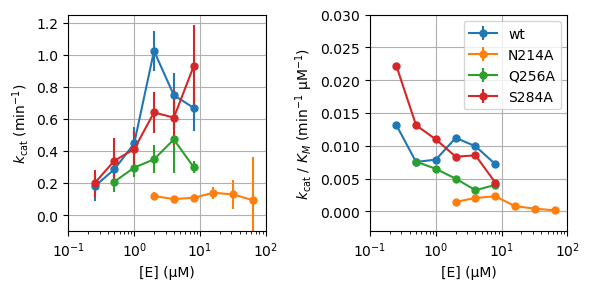

In [125]:
plt.figure(figsize=(6,3))

ax_l = plt.subplot(121)
for mutant in mutants:
    df = pd.DataFrame(resulting_data[mutant])
    ax_l.errorbar(df["[E] (µM)"], df["kcat (1/min)"], yerr=df["CI95(kcat) (1/min)"], fmt=".-", markersize=10)

ax_l.set_xscale("log")
ax_l.set_xlim([0.1, 100])
ax_l.set_ylim([-.1, 1.25])
ax_l.set_xlabel("[E] (µM)")
ax_l.set_ylabel("$k_\mathrm{cat}$ (min$^{-1}$)")
ax_l.grid()

ax_r = plt.subplot(122)
for mutant in mutants:
    df = pd.DataFrame(resulting_data[mutant])
    specificity = df["kcat (1/min)"] / df["Km (µM)"]
    error = 0.0 # complex... ratio distribution
    ax_r.errorbar(df["[E] (µM)"], specificity, yerr=error, fmt=".-", markersize=10)

ax_r.set_xscale("log")
ax_r.set_xlabel("[E] (µM)")
ax_r.set_ylabel("$k_\mathrm{cat}$ / $K_M$ (min$^{-1}$ µM$^{-1}$)")
ax_r.set_xlim([0.1, 100])
ax_r.set_ylim([-.003, 0.03])
ax_r.grid()

ax_r.legend(mutants)

plt.tight_layout()
plt.savefig('figures/mm_each_concentration_independently-mm_parameters.pdf')
plt.show()

In [123]:
# write v0 data to excel
with pd.ExcelWriter('fit_michaelis-menten_parameters.xlsx') as writer:
    for mutant in mutants:
        df = pd.DataFrame(resulting_data[mutant])
        df.to_excel(writer, sheet_name=mutant, index=False)